# Winter-wheat phenology from CLMS HRL Croplands

**The question this notebook answers:** can the Copernicus HRL Croplands suite give a
per-cell *winter wheat* sowing/emergence and harvest date, good enough to replace the
SAGE climatology that `site/calendar.py` currently samples?

Three layers, all 10 m, EPSG:3035, EEA reference grid, 100x100 km tiles, 2017-2024:

| Product | Content |
| --- | --- |
| `CTY` Crop Types | 20 classes; wheat is `1110` |
| `CPMCE` Main Crop Emergence | emergence date as `YYDOY` |
| `CPMCH` Main Crop Harvest | harvest date as `YYDOY` |

**The obstacle.** `CTY` does not separate winter from spring wheat -- class `1110` is
just "wheat".

**The hypothesis under test.** `CPMCE` encodes the emergence date as `YYDOY` *including
the year*, precisely because a season labelled 2023 can emerge in 2022. So for wheat
pixels of season year `Y`, emergence should be **bimodal**: a winter mode in the autumn
of `Y-1` and a spring mode inside `Y`. If that split is clean, the winter/spring
separation is an *observation* rather than an assumption, and it is available at 10 m
everywhere the product covers.

Everything downstream of that -- aggregating to the 0.1 degree target grid, comparing
against SAGE -- is only worth building if the bimodality holds. So this notebook tests
it on one small AOI before any pipeline code is written.

**Prerequisites.** A CLMS service key at `~/.clms` (created from the CLMS portal), and an
environment with `rasterio` / `rioxarray` / `pyjwt` (`dev_env` on this machine).

## 1. Setup

The AOI is Brandenburg -- the same area as the existing Germany smoke test, so anything
found here can be checked against `cropmodelling4eu/evaluation/germany_smoke_evaluation.ipynb`.

In [1]:
from __future__ import annotations

import calendar
import io
import json
import shutil
import time
import zipfile
from dataclasses import asdict, dataclass
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import requests

API = "https://land.copernicus.eu/api"
KEY_FILE = Path.home() / ".clms"

# Brandenburg. Kept small on purpose: one FME job, a few hundred MB at most.
AOI_W, AOI_S, AOI_E, AOI_N = 12.0, 52.0, 13.5, 53.0
AOI_NAME = "brandenburg"   # goes in the filenames; keep it short and lowercase
# 2022 is the season this notebook's verdict reports, and the one already on disk, so a
# fresh run reproduces section 9 without queueing anything. Any other year submits a job.
SEASON_YEAR = 2022

# CLMS is a reference *input* to the site stage, not run output, so it lives beside the
# other reference datasets (cybench, EnSv8, PEP725, SAGE_crop_calendar) rather than in a
# notebook-relative folder or on scratch.
CLMS_ROOT = Path("/data01/FDS/muduchuru/Data/Agri/CLMS")
WORK = CLMS_ROOT / "aoi_probe"
WORK.mkdir(parents=True, exist_ok=True)

# CTY class values (from the CDSE STAC `classification:classes` of the CTY collection).
CTY_CLASSES = {
    0: "no cropland", 1110: "wheat", 1120: "barley", 1130: "maize", 1140: "rice",
    1150: "other cereals", 1210: "fresh vegetables", 1220: "dry pulses",
    1310: "potatoes", 1320: "sugar beet", 1410: "sunflower", 1420: "soybeans",
    1430: "rapeseed", 1440: "flax cotton and hemp", 2100: "grapes", 2200: "olives",
    2310: "fruits", 2320: "nuts", 3100: "unclassified annual crop",
    3200: "unclassified permanent crop", 65535: "outside area",
}
WHEAT = 1110

# CPMCE / CPMCH sentinels. Everything >= 65526 is a flag, not a date; 0 is "no annual
# cropland". Aggregating any of these as if it were a DOY is the obvious way to get a
# plausible-looking wrong answer, so they are masked before anything else happens.
DATE_FLAGS = {
    0: "no annual cropland", 65526: "fallow land", 65527: "no field geometry",
    65531: "insufficient observations", 65532: "no season delineation",
    65533: "season outside timeframe", 65535: "outside area",
}

## 2. Authenticate

The CLMS service key is an RSA private key plus the claims needed to sign a JWT
authorization grant, which is exchanged for a one-hour bearer token.

In [2]:
import jwt


def clms_token(key_file: Path = KEY_FILE) -> str:
    """Exchange the service key's signed JWT grant for a bearer token."""
    cfg = json.loads(key_file.read_text())
    now = int(time.time())
    grant = jwt.encode(
        {"iss": cfg["client_id"], "sub": cfg["user_id"], "aud": cfg["token_uri"],
         "iat": now, "exp": now + 3600},
        cfg["private_key"], algorithm="RS256",
    )
    r = requests.post(
        cfg["token_uri"],
        data={"grant_type": "urn:ietf:params:oauth:grant-type:jwt-bearer", "assertion": grant},
        headers={"Accept": "application/json"}, timeout=60,
    )
    r.raise_for_status()
    return r.json()["access_token"]


TOKEN = clms_token()
AUTH = {"Accept": "application/json", "Authorization": f"Bearer {TOKEN}"}
print("token acquired")


def refresh_auth() -> dict[str, str]:
    """Re-mint the bearer token and update the module-level AUTH in place."""
    global TOKEN, AUTH
    TOKEN = clms_token()
    AUTH = {"Accept": "application/json", "Authorization": f"Bearer {TOKEN}"}
    return AUTH


def task_status(task_id: str) -> dict:
    """One status poll, re-authenticating once if the token has expired.

    The bearer token lives one hour. Jobs on this queue have been observed sitting in
    `Queued` for *days*, so a `wait()` that captured AUTH once is guaranteed to 401
    before the job finishes -- which is exactly how the previous run of this notebook
    died at 14:08 after a single `Queued` poll. Refresh on 401 rather than treating it
    as a failure.
    """
    for attempt in (1, 2):
        r = requests.get(f"{API}/@datarequest_status_get", params={"TaskID": task_id},
                         headers=AUTH, timeout=60)
        if r.status_code == 401 and attempt == 1:
            refresh_auth()
            continue
        r.raise_for_status()
        st = r.json()
        # The endpoint answers either the single task or a {TaskID: task} mapping.
        return st if "Status" in st else st.get(str(task_id), st)
    raise RuntimeError("unreachable")


token acquired


## 3. Discover the datasets

A download needs two identifiers: the dataset `UID` and the
`DatasetDownloadInformationID` of the particular collection within it (each product also
publishes a separate confidence layer, which is a *different* download-information ID
under the same dataset).

In [3]:
WANTED = {
    "CTY":   "Crop Types 2017-present (raster 10 m), Europe, yearly",
    "CPMCE": "Main Crop Emergence 2017-present (raster 10 m), Europe, yearly",
    "CPMCH": "Main Crop Harvest 2017-present (raster 10 m), Europe, yearly",
}


@dataclass(slots=True)
class DatasetRef:
    code: str
    title: str
    uid: str
    download_id: str
    collection: str
    full_format: str


def discover(wanted: dict[str, str]) -> dict[str, DatasetRef]:
    r = requests.get(
        f"{API}/@search",
        params={"portal_type": "DataSet", "metadata_fields": ["UID", "dataset_download_information"],
                "b_size": 400},
        headers=AUTH, timeout=120,
    )
    r.raise_for_status()
    by_title = {it["title"]: it for it in r.json()["items"]}

    refs: dict[str, DatasetRef] = {}
    for code, title in wanted.items():
        it = by_title[title]
        # The dataset record from @search carries only the UID; the download-information
        # block lives on the dataset object itself.
        obj = requests.get(it["@id"], headers=AUTH, timeout=120).json()
        items = obj["dataset_download_information"]["items"]
        # Take the primary RASTER collection, never the confidence layer.
        primary = next(x for x in items if "confidence" not in x["collection"].lower())
        refs[code] = DatasetRef(code, title, it["UID"], primary["@id"],
                                primary["collection"], primary["full_format"])
    return refs


REFS = discover(WANTED)
# asdict, not vars: DatasetRef is slots=True and so has no __dict__.
pd.DataFrame([asdict(r) for r in REFS.values()])

,code,title,uid,download_id,collection,full_format
0,CTY,"Crop Types 2017-present (raster 10 m), Europe,...",0d4d0d517b824d22857e43c4ea6073c9,869dd60b-1cd7-414b-8281-4f5e4eaea8f1,Crop Types,Geotiff
1,CPMCE,Main Crop Emergence 2017-present (raster 10 m)...,325ff9b20fd648cbaee5cd4258f54604,7aaf78c5-43d0-46a0-bdc1-fd178d05c0a6,Main Crop Emergence,Geotiff
2,CPMCH,"Main Crop Harvest 2017-present (raster 10 m), ...",461193fa864d4a6d92de66be9111a4f5,89d9c3a4-8fca-4911-ae8c-948f0eddba8b,Main Crop Harvest,Geotiff


### What formats and projections will it give back?

Both `CTY` and `CPMCE`/`CPMCH` are categorical in the sense that matters here: one is a
class code, the other packs two fields into `YYDOY` and reserves the high values as
flags. Neither survives interpolation -- averaging class `1110` with `1130` gives `1120`,
"barley", and averaging `22300` with `23100` gives a date in the wrong year. Only
nearest-neighbour is safe on either.

So the request asks for `EPSG:3035`, the CRS all three are natively published in, to make
any resampling *unnecessary*.

**That is a hope about the FME job, not a guarantee from it.** The service clips
server-side, and nothing in the API contract promises the clip lands on the source grid
rather than a freshly-aligned one. So the next cell verifies it instead of assuming it:
native 10 m resolution, `EPSG:3035`, and — the part a shape comparison misses entirely —
an *identical affine transform* across all three layers. Two rasters can share a shape
and still sit half a pixel apart, and every step downstream pairs these three arrays
element-wise, so a silent offset would mask emergence dates with the wrong crop type and
still produce a perfectly plausible-looking histogram.

In [4]:
for code, ref in REFS.items():
    pr = requests.get(f"{API}/@projections", params={"uid": ref.uid}, headers=AUTH, timeout=60)
    fc = requests.get(f"{API}/@format_conversion_table", params={"uid": ref.uid}, headers=AUTH, timeout=60)
    print(f"--- {code}")
    print("   projections:", pr.json() if pr.ok else f"HTTP {pr.status_code}")
    print("   formats:", str(fc.json())[:300] if fc.ok else f"HTTP {fc.status_code}")

--- CTY
   projections: ['EPSG:4326', 'EPSG:3035', 'EPSG:3857', 'EPSG:4258', 'EPSG:32738', 'EPSG:32740', 'EPSG:32620', 'EPSG:32622']
   formats: {'GDB': {'GDB': True, 'GML': True, 'GPKG': True, 'Geojson': True, 'Geotiff': False, 'Netcdf': False, 'Shapefile': True, 'WFS': False}, 'GML': {'GDB': False, 'GML': True, 'GPKG': False, 'Geojson': False, 'Geotiff': False, 'Netcdf': False, 'Shapefile': False, 'WFS': False}, 'GPKG': {'GDB': True, 'GML'
--- CPMCE
   projections: ['EPSG:4326', 'EPSG:3035', 'EPSG:3857', 'EPSG:4258', 'EPSG:32738', 'EPSG:32740', 'EPSG:32620', 'EPSG:32622']
   formats: {'GDB': {'GDB': True, 'GML': True, 'GPKG': True, 'Geojson': True, 'Geotiff': False, 'Netcdf': False, 'Shapefile': True, 'WFS': False}, 'GML': {'GDB': False, 'GML': True, 'GPKG': False, 'Geojson': False, 'Geotiff': False, 'Netcdf': False, 'Shapefile': False, 'WFS': False}, 'GPKG': {'GDB': True, 'GML'
--- CPMCH
   projections: ['EPSG:4326', 'EPSG:3035', 'EPSG:3857', 'EPSG:4258', 'EPSG:32738', 'EPSG:32740',

## 4. Request the clipped rasters

Two details of `@datarequest_post` that are easy to get wrong:

- **`BoundingBox` coordinate order.** The prose says `[N, E, S, W]` but the worked
  example in the same page is `[2.354, 46.852, 4.639, 45.882]` for a French AOI --
  longitude first, i.e. `[W, N, E, S]`. The example has to win: read as `[N, E, S, W]`
  those numbers put northern France at latitude 2.35. The returned raster bounds are
  checked against the AOI below, so a wrong guess shows up immediately rather than
  silently returning the wrong place.
- **`TemporalFilter` is epoch milliseconds**, and the portal caps a single request at
  366 days -- fine for a yearly product, one request per season year.

In [5]:
def epoch_ms(d: date) -> int:
    # calendar.timegm, NOT time.mktime: mktime reads the tuple as *local* time, so on a
    # UTC+1 machine `date(Y, 1, 1)` becomes Y-1-12-31T23:00Z. That one hour reaches back
    # into the previous season's product, and the service then labels the delivered
    # folder with the wrong year -- the 2022 request came back under `20210101/`. The
    # payload was still season 2022 (verified by decoding), but a filter that straddles
    # two seasons is one FME scheduling decision away from returning the wrong one.
    return calendar.timegm(d.timetuple()) * 1000


def submit(refs: dict[str, DatasetRef], year: int) -> str:
    payload = {"Datasets": [
        {
            "DatasetID": ref.uid,
            "DatasetDownloadInformationID": ref.download_id,
            "OutputFormat": "Geotiff",
            "OutputGCS": "EPSG:3035",
            # [W, N, E, S] -- see the note above.
            "BoundingBox": [AOI_W, AOI_N, AOI_E, AOI_S],
            "TemporalFilter": {"StartDate": epoch_ms(date(year, 1, 1)),
                               "EndDate": epoch_ms(date(year, 12, 31))},
        }
        for ref in refs.values()
    ]}
    r = requests.post(f"{API}/@datarequest_post", json=payload,
                      headers={**AUTH, "Content-Type": "application/json"}, timeout=120)
    # 400 is normally the duplicate guard, and its message is the useful part --
    # raise_for_status would throw it away.
    if r.status_code == 400:
        raise RuntimeError(f"request refused: {r.text}")
    r.raise_for_status()
    body = r.json()
    if body.get("ErrorTaskIds"):
        raise RuntimeError(f"request rejected: {body['ErrorTaskIds']}")
    return body["TaskIds"][0]["TaskID"]


# --- Queue history, recorded because it is a finding, not an aside -------------------
#
# 66068647426  Brandenburg 2023. Registered 2026-08-25T11:53:53Z, sat `Queued` for six
#              days, then went to `Cancelled` -- so it was never going to deliver, and
#              its mere existence blocked re-requesting 2023 via the duplicate guard.
# 3852689621   Brandenburg 2022. Registered 2026-08-31 as a diagnostic (a *different*
#              clip, so the guard allows it) and reached `Finished_ok` in **4 minutes**.
#
# That pair is the finding: the service is fast and healthy. A job stuck in `Queued` for
# days is an individually dead task, not a busy queue -- clear it from the download cart
# and resubmit rather than waiting.
#
# The duplicate guard matters to anyone re-running this. @datarequest_post answers
# 400 "You have requested to download the same thing at least twice" for an identical
# AOI/year/dataset triple while an earlier task is still alive, and there is no API to
# cancel one -- @datarequest_delete and @datarequest_cancel are both 404. The stale item
# has to be removed from the download cart in the CLMS web portal.
TASKS = {2022: "3852689621"}
# 2023's task (66068647426) is deliberately NOT listed: it died, and a dead id here is
# worse than none -- `wait()` would stop the notebook on it every run.

DEAD = ("Cancelled", "Finished_nok", "Rejected")


def resolve_task(year: int) -> str:
    """Reuse the recorded task for `year` if it is still alive, else queue a new one.

    A recorded id is only worth reusing while the task behind it exists. Tasks do die --
    66068647426 sat `Queued` for six days and then went `Cancelled` -- and a hard-coded
    dead id turns every later run into the same failure. So the status is checked before
    the id is trusted, and a dead one is replaced rather than raised on.
    """
    recorded = TASKS.get(year)
    if recorded:
        status = task_status(recorded).get("Status")
        if status not in DEAD:
            print(f"reusing task {recorded} for {year} (status {status})")
            return recorded
        print(f"recorded task {recorded} for {year} is {status} -- submitting a fresh one")
    fresh = submit(REFS, year)
    print(f"submitted task {fresh} for {year}")
    return fresh


TASK_ID = resolve_task(SEASON_YEAR)
print("TaskID:", TASK_ID)

reusing task 3852689621 for 2022 (status Finished_ok)
TaskID: 3852689621


### Poll until ready

The portal also emails when the job finishes; polling `@datarequest_status_get` gets the
same `DownloadURL` without leaving the notebook. Jobs of this size typically take a few
minutes, but the queue is shared, so the timeout is generous.

In [6]:
def wait(task_id: str, timeout_s: int = 3600, every_s: int = 60) -> dict:
    started = time.time()
    deadline = started + timeout_s
    seen = None
    while time.time() < deadline:
        task = task_status(task_id)
        status = task.get("Status")
        if status != seen:
            print(f"[{time.strftime('%H:%M:%S')}] {status} -- {task.get('Message', '')}")
            seen = status
        if status == "Finished_ok":
            return task
        if status and status.startswith(("Finished_nok", "Cancelled", "Rejected")):
            raise RuntimeError(f"download failed: {task}")
        time.sleep(every_s)

    registered = task_status(task_id).get("RegistrationDateTime", "?")
    raise TimeoutError(
        f"task {task_id} still {seen} after {timeout_s}s in this cell "
        f"(registered {registered}).\n"
        "The FME queue is shared and has been observed stalling for days. If this "
        "persists, the bulk CDSE route in the appendix is the way through -- and note "
        "that @datarequest_post REFUSES an identical re-request "
        "('you have requested to download the same thing at least twice') until the "
        "stale item is removed from the download cart in the CLMS web portal."
    )


TASK = wait(TASK_ID)
print("size: %.1f MB" % (TASK["FileSize"] / 1e6))
print("url:", TASK["DownloadURL"])

[15:17:27] Finished_ok -- Download process finished successfully
size: 13.0 MB
url: https://copernicus-fme.eea.europa.eu/fmedatadownload/results/103890.zip


In [7]:
ZIP_PATH = WORK / f"clms_{SEASON_YEAR}_task{TASK_ID}.zip"
EXTRACT = WORK / f"{SEASON_YEAR}"
expected = int(TASK.get("FileSize") or 0)


def fetch_zip(url: str, dest: Path, expect_bytes: int = 0) -> None:
    """Download once. A complete `dest` is left alone; anything else is refetched.

    The size check is the point. A bare `dest.exists()` guard keeps a *partial* file
    forever -- an interrupted download, a killed kernel, a full disk -- and the next run
    sails past it into a truncated archive. So the transfer lands on a `.part` sibling and
    is only renamed into place once it is complete, which means `dest` existing is itself
    the proof that it finished; `expect_bytes` (the API's own `FileSize`) is the second,
    independent check for a file left behind by an older, weaker version of this cell.
    """
    if dest.exists() and (not expect_bytes or dest.stat().st_size == expect_bytes):
        print(f"cached: {dest.name} ({dest.stat().st_size / 1e6:.1f} MB)")
        return
    if dest.exists():
        print(f"re-fetching {dest.name}: {dest.stat().st_size:,} B on disk, "
              f"{expect_bytes:,} B expected")

    part = dest.with_suffix(dest.suffix + ".part")
    # A browser User-Agent is required: the FME result host answers 403 to
    # python-requests' default UA, which looks exactly like an auth failure and is not.
    with requests.get(url, headers={"User-Agent": "Mozilla/5.0"},
                      stream=True, timeout=1800) as r:
        r.raise_for_status()
        with part.open("wb") as fh:
            for chunk in r.iter_content(1 << 20):
                fh.write(chunk)

    got = part.stat().st_size
    if expect_bytes and got != expect_bytes:
        part.unlink()
        raise IOError(f"{dest.name}: got {got:,} B, expected {expect_bytes:,} B")
    part.rename(dest)
    print(f"downloaded: {dest.name} ({got / 1e6:.1f} MB)")


CODES = ("CTY", "CPMCE", "CPMCH")


def canonical(code: str) -> Path:
    """Where layer `code` lives once renamed.

    The delivery names the rasters `CLMS_HRLVLCC_<CODE>_bbox_<i>.tif`, where `<i>` is the
    dataset's *position in the request payload* -- CTY came back `bbox_0` and CPMCH
    `bbox_1` only because of the order they were listed in. Reorder the request and the
    same name means a different layer. Worse, they arrive under a folder named for the
    temporal filter's start (`20210101/`) rather than the season they describe, which for
    season 2022 is off by a year and actively misleading.

    So they are renamed to the product's own tile convention, with the season and AOI in
    the name and nothing positional:

        CLMS_HRLVLCC_CPMCE_S2022_R10m_brandenburg_03035.tif

    matching the published tiles (`CLMS_HRLVLCC_CPMCE_S2017_R10m_E40N28_03035_V01_R00`)
    with the EEA tile id replaced by the AOI slug.
    """
    return WORK / f"CLMS_HRLVLCC_{code}_S{SEASON_YEAR}_R10m_{AOI_NAME}_03035.tif"


LAYER_PATHS = {c: canonical(c) for c in CODES}

# The renamed rasters -- not the zip, and not the delivery tree -- are the artefact
# everything downstream reads, so they are what idempotence keys on. If all three are in
# place there is nothing to download and nothing to unpack.
if all(p.exists() for p in LAYER_PATHS.values()):
    print("cached: all three layers already extracted and renamed")
else:
    fetch_zip(TASK["DownloadURL"], ZIP_PATH, expected)
    with zipfile.ZipFile(ZIP_PATH) as z:
        z.extractall(EXTRACT)

    for code, dest in LAYER_PATHS.items():
        hits = [t for t in EXTRACT.rglob("*.tif") if f"_{code}_" in t.name.upper()]
        if len(hits) != 1:
            raise FileNotFoundError(
                f"expected exactly one {code} raster in {EXTRACT}, found {len(hits)}: "
                f"{[h.name for h in hits]}"
            )
        hits[0].replace(dest)
        print(f"{code:6s} -> {dest.name}")

    # The delivery tree now holds only legends and empty directories; the rasters have
    # moved out of it. Drop it so a later run cannot read a stale copy under the
    # misleading `20210101/` folder.
    shutil.rmtree(EXTRACT, ignore_errors=True)

for code, path in LAYER_PATHS.items():
    print(f"{path.stat().st_size / 1e6:8.1f} MB  {path.name}")

cached: all three layers already extracted and renamed
   243.9 MB  CLMS_HRLVLCC_CTY_S2022_R10m_brandenburg_03035.tif
   243.9 MB  CLMS_HRLVLCC_CPMCE_S2022_R10m_brandenburg_03035.tif
   243.9 MB  CLMS_HRLVLCC_CPMCH_S2022_R10m_brandenburg_03035.tif


## 5. Load and decode

`YYDOY` unpacks as `YY = value // 1000`, `DOY = value % 1000`. Rather than keep a raw
DOY -- which wraps at New Year and makes "the mean of DOY 300 and DOY 40" a meaningless
number -- every date is converted to an **absolute date** and then expressed as days
since an anchor of **1 August of `SEASON_YEAR - 1`**. On that axis a winter-wheat
emergence lands near +30..+120 and its harvest near +330..+380, both monotone, so an
ordinary median aggregates them correctly and no circular statistics are needed.

In [8]:
import rioxarray  # noqa: F401
import xarray as xr


def open_layer(code: str) -> xr.DataArray:
    """Open one renamed layer by product code."""
    da = rioxarray.open_rasterio(LAYER_PATHS[code], masked=False).squeeze("band", drop=True)
    da.name = code.lower()
    return da


ANCHOR = date(SEASON_YEAR - 1, 8, 1)


def decode_yydoy(da: xr.DataArray) -> tuple[xr.DataArray, xr.DataArray]:
    """Return (days since ANCHOR, flag code). Non-dates come back as NaN days."""
    v = da.astype("int32")
    is_date = (v > 0) & (v < 65526)
    yy = xr.where(is_date, v // 1000, 0)
    doy = xr.where(is_date, v % 1000, 1)

    # Absolute day number, built without a Python-level date loop: days from ANCHOR to
    # 1 Jan of the emergence year, plus DOY-1.
    years = np.unique(yy.values[is_date.values]) if is_date.any() else np.array([], dtype=int)
    offset = xr.zeros_like(yy)
    for y in years:
        jan1 = date(2000 + int(y), 1, 1)
        offset = xr.where(yy == y, (jan1 - ANCHOR).days, offset)

    days = xr.where(is_date, offset + doy - 1, np.nan).astype("float32")
    flag = xr.where(is_date, 0, v).astype("int32")
    return days, flag


cty = open_layer("CTY")
cpmce_raw = open_layer("CPMCE")
cpmch_raw = open_layer("CPMCH")

LAYERS = {"CTY": cty, "CPMCE": cpmce_raw, "CPMCH": cpmch_raw}
for code, da in LAYERS.items():
    print(f"{code:6s} shape={str(da.shape):16s} crs={da.rio.crs} "
          f"res={tuple(round(v, 3) for v in da.rio.resolution())} dtype={da.dtype}")

CTY    shape=(11505, 10601)   crs=IGNF:ETRS89LAEA res=(10.0, -10.0) dtype=uint16
CPMCE  shape=(11505, 10601)   crs=IGNF:ETRS89LAEA res=(10.0, -10.0) dtype=uint16
CPMCH  shape=(11505, 10601)   crs=IGNF:ETRS89LAEA res=(10.0, -10.0) dtype=uint16


In [9]:
def check_grids(layers: dict[str, xr.DataArray], expect_epsg: int = 3035,
                expect_res: float = 10.0) -> None:
    """Fail loudly if the service did not return the native, mutually aligned grid."""
    ref_code, ref = next(iter(layers.items()))

    problems: list[str] = []
    for code, da in layers.items():
        # The service labels the CRS `IGNF:ETRS89LAEA`, not `EPSG:3035`. It is the same
        # projection -- same LAEA method, same ETRS89 datum and GRS80 ellipsoid, and
        # byte-identical parameters (lat_0 52, lon_0 10, x_0 4321000, y_0 3210000). The
        # only difference is axis order: IGNF declares (east, north), EPSG:3035 formally
        # declares (north, east). GeoTIFF stores x/y anyway, so the pixels are right.
        #
        # That difference is enough to make a bare `to_epsg()` return None and
        # `CRS.equals` return False, either of which would fail a raster that is exactly
        # what was asked for. `to_epsg(min_confidence=20)` identifies it as 3035: the
        # confidence is docked only for the authority/axis mismatch, not the geodesy.
        from pyproj import CRS as _CRS
        if _CRS.from_wkt(da.rio.crs.to_wkt()).to_epsg(min_confidence=20) != expect_epsg:
            problems.append(f"{code}: CRS is {da.rio.crs} which is not equivalent to "
                            f"EPSG:{expect_epsg} -- the raster was reprojected")
        if not all(abs(abs(v) - expect_res) < 1e-6 for v in da.rio.resolution()):
            problems.append(f"{code}: resolution {da.rio.resolution()} is not "
                            f"{expect_res} m -- the raster was resampled")
        # The decisive test: same affine transform, not merely the same shape.
        #
        # rtol=0 is load-bearing. EPSG:3035 eastings are ~4e6, so np.allclose's default
        # rtol=1e-5 tolerates a 40 m disagreement -- four pixels -- and silently passes
        # a misaligned grid. Compare on an absolute tolerance of a thousandth of a pixel.
        tol = expect_res / 1000.0
        if da.shape != ref.shape or not np.allclose(
            np.array(da.rio.transform()).astype(float),
            np.array(ref.rio.transform()).astype(float), rtol=0.0, atol=tol
        ):
            problems.append(f"{code}: grid differs from {ref_code}\n"
                            f"       {code}: shape {da.shape} transform {tuple(da.rio.transform())[:6]}\n"
                            f"       {ref_code}: shape {ref.shape} transform {tuple(ref.rio.transform())[:6]}")

    if problems:
        raise AssertionError(
            "layers are NOT pixel-aligned; element-wise masking below would pair the "
            "wrong pixels:\n  - " + "\n  - ".join(problems)
            + "\n\nFix by aligning explicitly with nearest-neighbour before masking, e.g.\n"
              "    cpmce_raw = cpmce_raw.rio.reproject_match(cty, resampling=Resampling.nearest)\n"
              "NEVER with the default bilinear -- see the note above."
        )
    print(f"OK: all {len(layers)} layers on the native EPSG:{expect_epsg} "
          f"{expect_res:g} m grid, identical transforms")
    print("   transform:", tuple(round(v, 2) for v in tuple(ref.rio.transform())[:6]))
    print("   bounds:   ", tuple(round(v, 1) for v in ref.rio.bounds()))


check_grids(LAYERS)

emergence_days, emergence_flag = decode_yydoy(cpmce_raw)
harvest_days, harvest_flag = decode_yydoy(cpmch_raw)

OK: all 3 layers on the native EPSG:3035 10 m grid, identical transforms
   transform: (10.0, 0.0, 4455260.0, 0.0, -10.0, 3326930.0)
   bounds:    (4455260.0, 3211880.0, 4561270.0, 3326930.0)


### Sanity checks before believing anything

If the bounding-box order was wrong, the reprojected bounds will not contain the AOI and
this cell says so.

Two details decide whether it *can* say so. The AOI must be **densified before
projecting** -- a lon/lat box is not a rectangle in LAEA, its east-west edges bow
outward, and projecting only the two corners understates the true extent by ~3 km here,
which would let a badly short raster pass. And the comparison needs **one pixel of
slack**, because the service snaps its clip to the source grid and an edge can land a
fraction of a pixel inside the request. A real coordinate-order mistake is off by
hundreds of kilometres, never by metres.

In [10]:
from pyproj import Transformer

to_3035 = Transformer.from_crs("EPSG:4326", "EPSG:3035", always_xy=True)

# Densify the AOI boundary before projecting it. A lon/lat box is NOT a rectangle in
# LAEA -- its east-west edges bow outward -- so projecting only the SW and NE corners
# *understates* the true extent. Here the corners give x 4458336..4555888 while the real
# extent is x 4455262..4561266: the corner-only test would have accepted a raster 3 km
# short on each side, which is precisely the failure it exists to catch.
n = 400
lons = np.linspace(AOI_W, AOI_E, n)
lats = np.linspace(AOI_S, AOI_N, n)
bx, by = to_3035.transform(
    np.r_[lons, lons, np.full(n, AOI_W), np.full(n, AOI_E)],
    np.r_[np.full(n, AOI_S), np.full(n, AOI_N), lats, lats],
)
x0, x1, y0, y1 = bx.min(), bx.max(), by.min(), by.max()

left, bottom, right, top = cty.rio.bounds()
# One pixel of slack. The service snaps the clip to the source grid, so an edge may land
# a fraction of a pixel inside the request -- here the north edge is 4.4 m short of a
# 10 m pixel. That is a correct clip, not a wrong one. A genuine BoundingBox-order
# mistake puts the raster in a different country, so it is never within a pixel.
tol = max(abs(v) for v in cty.rio.resolution())
short = {"west": left - x0, "south": bottom - y0, "east": x1 - right, "north": y1 - top}
worst = {k: v for k, v in short.items() if v > tol}

print(f"AOI in EPSG:3035: x {x0:.0f}..{x1:.0f}  y {y0:.0f}..{y1:.0f}")
print(f"raster bounds   : x {left:.0f}..{right:.0f}  y {bottom:.0f}..{top:.0f}")
print("shortfall (m)   : " + "  ".join(f"{k} {max(v, 0.0):.1f}" for k, v in short.items())
      + f"   [tolerance {tol:g} m = 1 pixel]")
print("AOI covered:", not worst)
assert not worst, (
    f"returned raster misses the AOI by more than one pixel on: {worst} "
    "-- check the BoundingBox order ([W, N, E, S])"
)

AOI in EPSG:3035: x 4455262..4561266  y 3211884..3326934
raster bounds   : x 4455260..4561270  y 3211880..3326930
shortfall (m)   : west 0.0  south 0.0  east 0.0  north 4.4   [tolerance 10 m = 1 pixel]
AOI covered: True


In [11]:
counts = pd.Series(cty.values.ravel()).value_counts()
crop_mix = (
    pd.DataFrame({"pixels": counts})
    .assign(name=lambda d: d.index.map(lambda v: CTY_CLASSES.get(int(v), f"<{v}>")),
            pct=lambda d: 100 * d.pixels / d.pixels.sum())
    .sort_values("pixels", ascending=False)
)
crop_mix.head(12)

,pixels,name,pct
0,91335785,no cropland,74.887185
1150,8216753,other cereals,6.737004
1130,6121006,maize,5.018678
1110,4592347,wheat,3.765314
1120,3478766,barley,2.852277
1430,3203691,rapeseed,2.626740
1210,1672242,fresh vegetables,1.371089
3100,643192,unclassified annual crop,0.527360
1310,599007,potatoes,0.491132
1410,581123,sunflower,0.476469


### What the wheat mask actually looks like

`CTY == 1110` is the mask every date below is drawn through, so it is worth seeing before
trusting any of them.

**A full-AOI panel cannot show 10 m.** The raster is 10 601 x 11 505 pixels across 106 km;
rendered a few hundred pixels wide, roughly one pixel in fifteen survives. So the left
panel is for *distribution* and the right panel -- the densest 10 x 10 km window, drawn at
one screen pixel per raster pixel -- is where the 10 m detail is real and individual
parcels are visible.

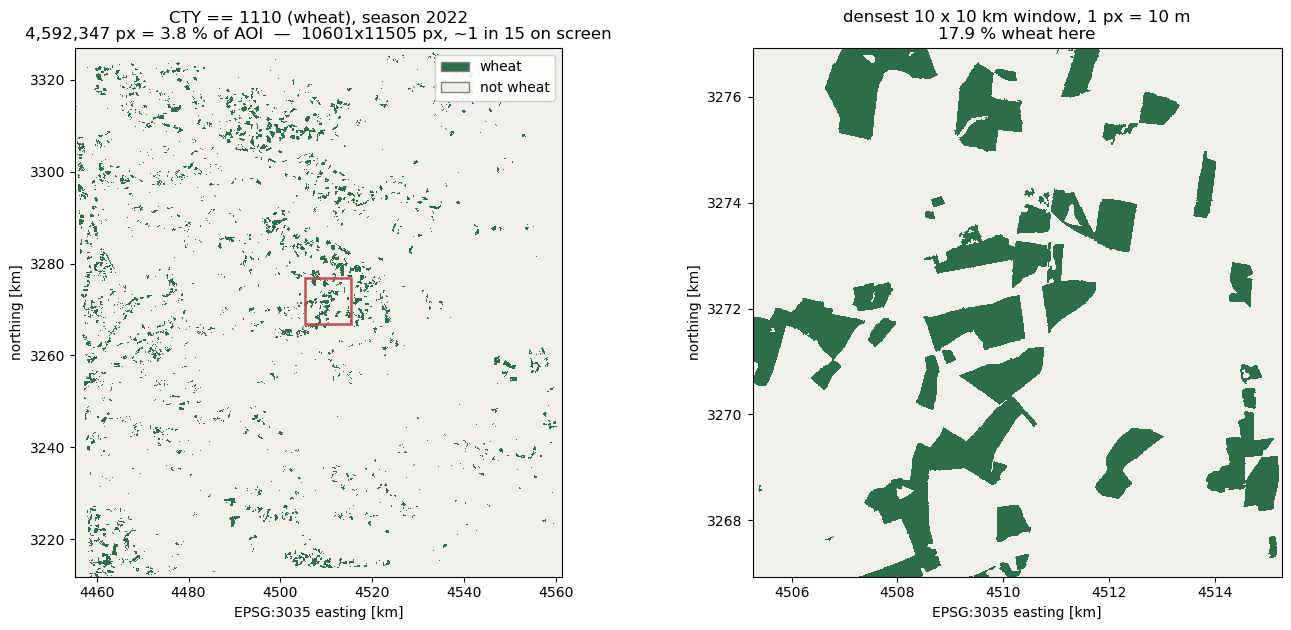

In [12]:
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from matplotlib.patches import Rectangle

is_wheat = (cty == WHEAT).values
res = abs(cty.rio.resolution()[0])
left, bottom, right, top = cty.rio.bounds()

# Choose the zoom window by evidence rather than by eye: the densest 10 km block.
BLK = int(10_000 / res)
nr, nc = is_wheat.shape[0] // BLK, is_wheat.shape[1] // BLK
dens = is_wheat[:nr * BLK, :nc * BLK].reshape(nr, BLK, nc, BLK).sum((1, 3))
r0, c0 = np.unravel_index(dens.argmax(), dens.shape)
rs, cs = slice(r0 * BLK, (r0 + 1) * BLK), slice(c0 * BLK, (c0 + 1) * BLK)
zoom = is_wheat[rs, cs]

zl, zr = left + cs.start * res, left + cs.stop * res
zt, zb = top - rs.start * res, top - rs.stop * res

cmap = ListedColormap(["#F2F0EB", "#2C6E49"])   # not wheat, wheat
km = lambda v: v / 1000.0

fig, axes = plt.subplots(1, 2, figsize=(14, 6.4))

# `interpolation="nearest"` is load-bearing on a categorical layer. Matplotlib's default
# resampling AVERAGES neighbouring pixels when downscaling, which on a 0/1 mask paints
# fractional values -- a smear of intermediate colour that reads as "partly wheat" and
# corresponds to nothing in the data. The same reason the aggregation below bins pixel
# centres instead of resampling.
axes[0].imshow(is_wheat, extent=[km(left), km(right), km(bottom), km(top)],
               cmap=cmap, vmin=0, vmax=1, interpolation="nearest", origin="upper")
axes[0].add_patch(Rectangle((km(zl), km(zb)), km(zr - zl), km(zt - zb),
                            fill=False, ec="#C44E52", lw=1.8))
axes[0].set_title(f"CTY == {WHEAT} (wheat), season {SEASON_YEAR}\n"
                  f"{is_wheat.sum():,} px = {100 * is_wheat.mean():.1f} % of AOI"
                  f"  —  {is_wheat.shape[1]}x{is_wheat.shape[0]} px, ~1 in 15 on screen")

axes[1].imshow(zoom, extent=[km(zl), km(zr), km(zb), km(zt)],
               cmap=cmap, vmin=0, vmax=1, interpolation="nearest", origin="upper")
axes[1].set_title(f"densest 10 x 10 km window, 1 px = {res:g} m\n"
                  f"{100 * zoom.mean():.1f} % wheat here")

for ax in axes:
    ax.set_xlabel("EPSG:3035 easting [km]")
    ax.set_ylabel("northing [km]")
    ax.set_aspect("equal")
axes[0].legend([plt.Rectangle((0, 0), 1, 1, fc=cmap(i), ec="0.5") for i in (1, 0)],
               ["wheat", "not wheat"], loc="upper right", framealpha=0.9)
fig.tight_layout()

In [13]:
flag_mix = (
    pd.Series(emergence_flag.values.ravel()).value_counts()
    .rename_axis("flag").to_frame("pixels")
    .assign(name=lambda d: d.index.map(lambda v: DATE_FLAGS.get(int(v), "valid date" if v == 0 else f"<{v}>")),
            pct=lambda d: 100 * d.pixels / d.pixels.sum())
)
# flag 0 here means "decoded to a real date"; the CPMCE value 0 ("no annual cropland")
# also lands in the same bucket, so it is separated out explicitly.
no_cropland = int((cpmce_raw == 0).sum())
print(f"pixels with CPMCE == 0 (no annual cropland): {no_cropland:,}")
flag_mix

pixels with CPMCE == 0 (no annual cropland): 92,000,279


,pixels,name,pct
flag,,,
0,119458006,no annual cropland,97.944895
65527,1217225,no field geometry,0.998016
65533,1164258,season outside timeframe,0.954588
65532,109397,no season delineation,0.089696
65526,15619,fallow land,0.012806


## 6. The hypothesis test

For wheat pixels of season `SEASON_YEAR`, in which calendar year does emergence fall?

If the winter/spring split is real, this histogram is **bimodal**: an autumn peak in
`SEASON_YEAR - 1` and a spring peak in `SEASON_YEAR`. If instead everything piles into a
single spring mode, then `CPMCE` is reporting post-dormancy regrowth rather than true
autumn emergence -- which would make it no better than HR-VPP's `SOSD`, and the whole
approach collapses back to needing an external winter/spring wheat map.

In [14]:
wheat = cty == WHEAT
valid = wheat & np.isfinite(emergence_days)
print(f"wheat pixels: {int(wheat.sum()):,}  ({100 * float(wheat.mean()):.1f}% of AOI)")
print(f"  ... with a decoded emergence date: {int(valid.sum()):,} "
      f"({100 * int(valid.sum()) / max(int(wheat.sum()), 1):.1f}%)")

wd = emergence_days.values[valid.values]
hd = harvest_days.values[(wheat & np.isfinite(harvest_days)).values]
print(f"emergence, days since {ANCHOR}: min {wd.min():.0f}  median {np.median(wd):.0f}  max {wd.max():.0f}")

wheat pixels: 4,592,347  (3.8% of AOI)
  ... with a decoded emergence date: 4,428,139 (96.4%)
emergence, days since 2021-08-01: min 14  median 89  max 422


2021    3293257
2022    1134882
Name: count, dtype: int64


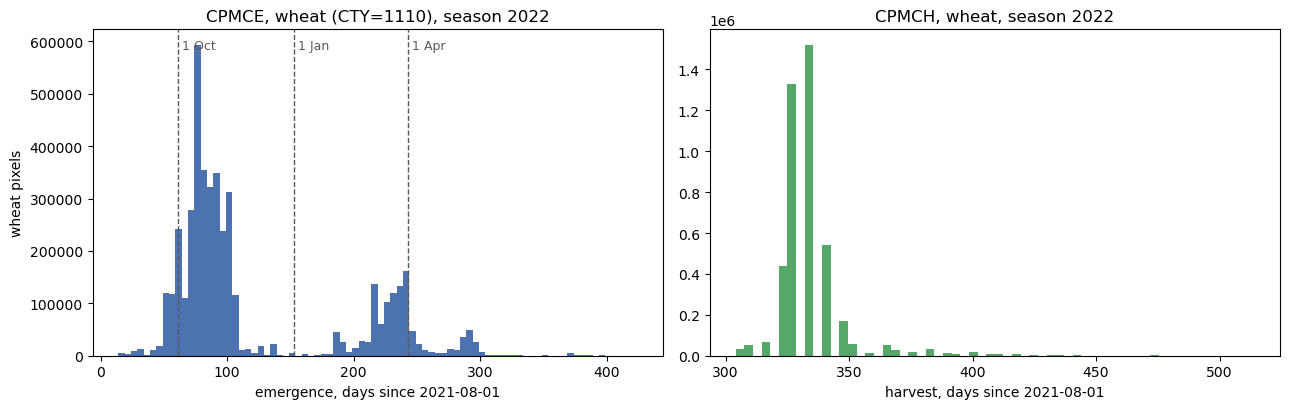

In [15]:
import matplotlib.pyplot as plt

emergence_year = (cpmce_raw.where(valid) // 1000 + 2000)
year_counts = pd.Series(emergence_year.values.ravel()).dropna().astype(int).value_counts().sort_index()
print(year_counts)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

axes[0].hist(wd, bins=np.arange(np.floor(wd.min()), np.ceil(wd.max()) + 5, 5),
             color="#4C72B0", edgecolor="none")
axes[0].set_xlabel(f"emergence, days since {ANCHOR}")
axes[0].set_ylabel("wheat pixels")
axes[0].set_title(f"CPMCE, wheat (CTY={WHEAT}), season {SEASON_YEAR}")
for lab, off in [("1 Oct", (date(SEASON_YEAR - 1, 10, 1) - ANCHOR).days),
                 ("1 Jan", (date(SEASON_YEAR, 1, 1) - ANCHOR).days),
                 ("1 Apr", (date(SEASON_YEAR, 4, 1) - ANCHOR).days)]:
    axes[0].axvline(off, color="0.35", ls="--", lw=1)
    axes[0].text(off, axes[0].get_ylim()[1] * 0.94, f" {lab}", fontsize=9, color="0.35")

axes[1].hist(hd, bins=60, color="#55A868", edgecolor="none")
axes[1].set_xlabel(f"harvest, days since {ANCHOR}")
axes[1].set_title(f"CPMCH, wheat, season {SEASON_YEAR}")

fig.tight_layout()

### Split, and check the split against season length

The cut is placed at 1 January of the season year: emergence before it is winter wheat,
after it is spring wheat.

The split is only trustworthy if it survives an *independent* check, so the season length
`harvest - emergence` is the test. Winter wheat in Brandenburg should run roughly
250-320 days; spring wheat roughly 100-160. If both classes return the same season
length, the "winter" mode is not winter wheat and the split is an artefact.

In [16]:
CUT = (date(SEASON_YEAR, 1, 1) - ANCHOR).days

season_len = harvest_days - emergence_days
both = wheat & np.isfinite(emergence_days) & np.isfinite(season_len)
is_winter = both & (emergence_days < CUT)
is_spring = both & (emergence_days >= CUT)

rows = []
for label, m in [("winter (emerged before 1 Jan)", is_winter), ("spring (emerged after 1 Jan)", is_spring)]:
    e = emergence_days.values[m.values]
    s = season_len.values[m.values]
    if e.size == 0:
        continue
    rows.append({
        "class": label, "pixels": int(m.sum()), "pct_of_wheat": 100 * int(m.sum()) / int(both.sum()),
        "emergence_median": float(np.median(e)),
        "emergence_date": str(ANCHOR + timedelta(days=float(np.median(e)))),
        "season_len_median": float(np.median(s)),
        "season_len_p10": float(np.percentile(s, 10)),
        "season_len_p90": float(np.percentile(s, 90)),
    })
pd.DataFrame(rows)

,class,pixels,pct_of_wheat,emergence_median,emergence_date,season_len_median,season_len_p10,season_len_p90
0,winter (emerged before 1 Jan),3293257,74.37113,79.0,2021-10-19,251.0,228.0,275.0
1,spring (emerged after 1 Jan),1134882,25.62887,233.0,2022-03-22,101.0,79.0,134.0


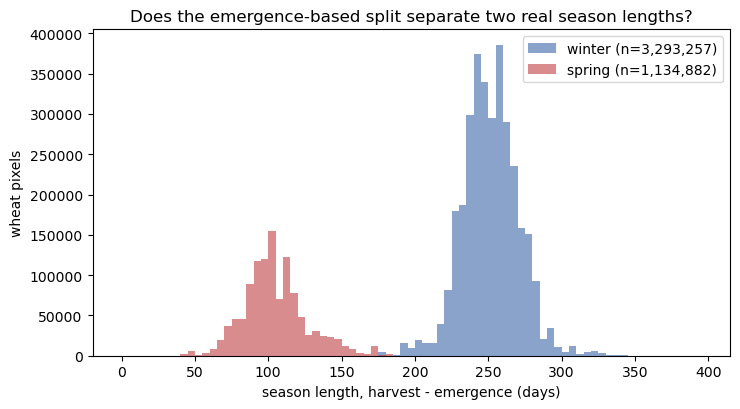

In [17]:
fig, ax = plt.subplots(figsize=(7.5, 4.2))
for label, m, c in [("winter", is_winter, "#4C72B0"), ("spring", is_spring, "#C44E52")]:
    s = season_len.values[m.values]
    if s.size:
        ax.hist(s, bins=np.arange(0, 400, 5), alpha=0.65, label=f"{label} (n={s.size:,})", color=c)
ax.set_xlabel("season length, harvest - emergence (days)")
ax.set_ylabel("wheat pixels")
ax.set_title("Does the emergence-based split separate two real season lengths?")
ax.legend()
fig.tight_layout()

### The split, at 10 m

The histograms above say the two modes are separable *statistically*. This says whether
they are separable **on the ground**, which is a different and stronger claim.

The classes come from the very same `is_winter` / `is_spring` masks the table was built
from, so the map cannot drift from the numbers. `wheat, no date` is wheat that lacks a
usable emergence/harvest pair — it is drawn rather than hidden, because a class that is
silently dropped is a class nobody audits.

Again the left panel is distribution only (~1 pixel in 15 survives at screen size); the
right panel is 1 screen pixel per raster pixel. Its window is chosen as the 10 km block
holding the most of the **rarer** class — the densest-wheat block would very likely be all
winter and show nothing of the split at all.

not wheat         117,372,158 px
wheat, no date        164,208 px
winter wheat        3,293,257 px
spring wheat        1,134,882 px


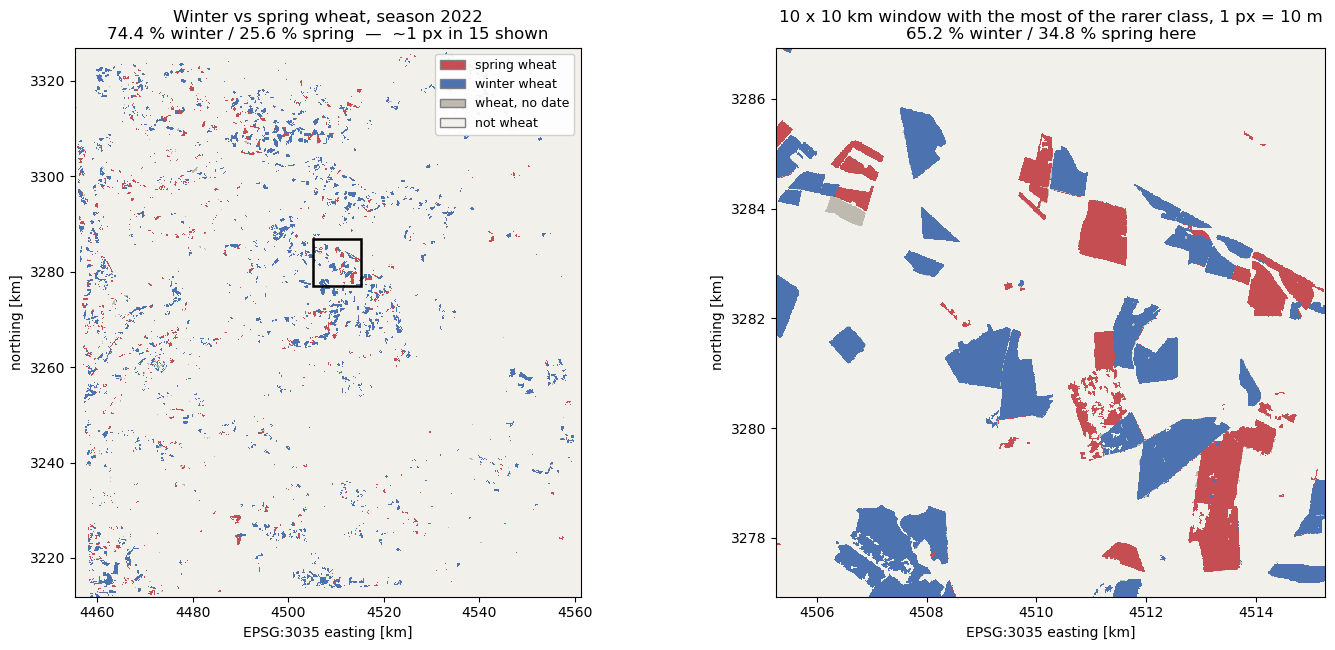

In [18]:
# 0 not wheat | 1 wheat, no usable date | 2 winter | 3 spring.
# Built from the same masks as the table above, not recomputed.
klass = np.zeros(wheat.shape, dtype=np.uint8)
klass[wheat.values] = 1
klass[is_winter.values] = 2
klass[is_spring.values] = 3

res = abs(cty.rio.resolution()[0])
left, bottom, right, top = cty.rio.bounds()

BLK = int(10_000 / res)
nr, nc = klass.shape[0] // BLK, klass.shape[1] // BLK
blocks = klass[:nr * BLK, :nc * BLK].reshape(nr, BLK, nc, BLK)
# Score each block by the count of its RARER class, so the window shows the split rather
# than whichever class dominates.
score = np.minimum((blocks == 2).sum((1, 3)), (blocks == 3).sum((1, 3)))
r0, c0 = np.unravel_index(score.argmax(), score.shape)
rs, cs = slice(r0 * BLK, (r0 + 1) * BLK), slice(c0 * BLK, (c0 + 1) * BLK)
zoom = klass[rs, cs]
zl, zr = left + cs.start * res, left + cs.stop * res
zt, zb = top - rs.start * res, top - rs.stop * res

COLORS = ["#F2F0EB", "#BFBAB0", "#4C72B0", "#C44E52"]   # matches the histograms above
LABELS = ["not wheat", "wheat, no date", "winter wheat", "spring wheat"]
cmap = ListedColormap(COLORS)
norm = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap.N)
km = lambda v: v / 1000.0

fig, axes = plt.subplots(1, 2, figsize=(14.5, 6.6))
for ax, arr, ext in (
    (axes[0], klass, [km(left), km(right), km(bottom), km(top)]),
    (axes[1], zoom, [km(zl), km(zr), km(zb), km(zt)]),
):
    ax.imshow(arr, extent=ext, cmap=cmap, norm=norm,
              interpolation="nearest", origin="upper")   # never average a class code
    ax.set_xlabel("EPSG:3035 easting [km]")
    ax.set_ylabel("northing [km]")
    ax.set_aspect("equal")

axes[0].add_patch(Rectangle((km(zl), km(zb)), km(zr - zl), km(zt - zb),
                            fill=False, ec="k", lw=1.8))
tot = (klass >= 2).sum()
axes[0].set_title(f"Winter vs spring wheat, season {SEASON_YEAR}\n"
                  f"{(klass == 2).sum() / tot * 100:.1f} % winter / "
                  f"{(klass == 3).sum() / tot * 100:.1f} % spring  —  ~1 px in 15 shown")
zt2 = (zoom >= 2).sum()
axes[1].set_title(f"10 x 10 km window with the most of the rarer class, 1 px = {res:g} m\n"
                  f"{(zoom == 2).sum() / zt2 * 100:.1f} % winter / "
                  f"{(zoom == 3).sum() / zt2 * 100:.1f} % spring here")
axes[0].legend([plt.Rectangle((0, 0), 1, 1, fc=c, ec="0.5") for c in COLORS[::-1]],
               LABELS[::-1], loc="upper right", framealpha=0.92, fontsize=9)
fig.tight_layout()

for i, lab in enumerate(LABELS):
    print(f"{lab:16s} {(klass == i).sum():>12,} px")

## 7. Aggregate to the 0.1 degree target grid

Following the ECIRA precedent in `CLAUDE.md`: bin the 10 m pixel **centres** into the
target cells rather than resampling, so no pixel is split and no date is interpolated.
The per-cell statistic is the **median** over winter-wheat pixels, on the
days-since-anchor axis.

Two extra fields travel with each cell, mirroring how the soil stage carries
`share_percent`: the number of contributing pixels, and the winter share of that cell's
wheat. A cell whose date rests on a handful of pixels is not the same evidence as one
resting on thousands, and the export should be able to say so.

In [ ]:
GRID_RES = 0.1

to_4326 = Transformer.from_crs(cty.rio.crs, "EPSG:4326", always_xy=True)
xs, ys = np.meshgrid(cty.x.values, cty.y.values)
m = is_winter.values
lon, lat = to_4326.transform(xs[m], ys[m])

cell_lon = np.floor(lon / GRID_RES) * GRID_RES + GRID_RES / 2
cell_lat = np.floor(lat / GRID_RES) * GRID_RES + GRID_RES / 2

per_pixel = pd.DataFrame({
    "cell_lon": np.round(cell_lon, 4),
    "cell_lat": np.round(cell_lat, 4),
    "emergence": emergence_days.values[m],
    "harvest": harvest_days.values[m],
})

cells = (
    per_pixel.groupby(["cell_lat", "cell_lon"])
    .agg(emergence_days=("emergence", "median"),
         harvest_days=("harvest", "median"),
         n_pixels=("emergence", "size"))
    .reset_index()
)

# Back to calendar dates and to the DOY the site stage speaks in.
cells["emergence_date"] = [ANCHOR + timedelta(days=float(d)) for d in cells.emergence_days]
cells["harvest_date"] = [ANCHOR + timedelta(days=float(d)) if np.isfinite(d) else pd.NaT
                         for d in cells.harvest_days]
cells["emergence_doy"] = [d.timetuple().tm_yday for d in cells.emergence_date]
cells["harvest_doy"] = [d.timetuple().tm_yday if pd.notna(d) else np.nan for d in cells.harvest_date]
cells["season_length_days"] = cells.harvest_days - cells.emergence_days

# Winter share of the cell's wheat: 1 - this is the fraction the exported date ignores.
wheat_lon, wheat_lat = to_4326.transform(xs[both.values], ys[both.values])
wheat_cells = (
    pd.DataFrame({"cell_lon": np.round(np.floor(wheat_lon / GRID_RES) * GRID_RES + GRID_RES / 2, 4),
                  "cell_lat": np.round(np.floor(wheat_lat / GRID_RES) * GRID_RES + GRID_RES / 2, 4)})
    .value_counts().rename("n_wheat").reset_index()
)
cells = cells.merge(wheat_cells, on=["cell_lat", "cell_lon"], how="left")
cells["winter_share"] = cells.n_pixels / cells.n_wheat

print(f"{len(cells)} target cells with winter wheat")
cells.sort_values("n_pixels", ascending=False).head(10)

### How thin is the evidence?

A 0.1 degree cell is ~74 km<sup>2</sup> here, i.e. ~740,000 pixels of 10 m. A cell whose
winter-wheat date rests on a few hundred of them is describing a couple of fields.

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(cells.n_pixels, bins=40, color="#4C72B0")
axes[0].set_xlabel("winter-wheat pixels per 0.1 deg cell")
axes[0].set_ylabel("cells")
axes[0].set_yscale("log")

sc = axes[1].scatter(cells.cell_lon, cells.cell_lat, c=cells.emergence_doy,
                     s=26, cmap="viridis")
axes[1].set_title("median emergence DOY")
fig.colorbar(sc, ax=axes[1])

sc2 = axes[2].scatter(cells.cell_lon, cells.cell_lat, c=cells.winter_share,
                      s=26, cmap="magma", vmin=0, vmax=1)
axes[2].set_title("winter share of the cell's wheat")
fig.colorbar(sc2, ax=axes[2])

for ax in axes[1:]:
    ax.set_xlabel("lon"); ax.set_ylabel("lat")
fig.tight_layout()

## 8. Compare against SAGE

The point of comparison. SAGE is a 0.5 degree climatology assembled from census
reporting units; CLMS is a 10 m observation of one particular year. They should agree
in the large and disagree in the detail -- and the *shape* of the disagreement is what
decides whether CLMS is worth wiring into `site/calendar.py`.

Remember the offset being compared: SAGE `plant` is a **sowing** date, CPMCE is an
**emergence** date. Autumn germination takes roughly 10-20 days, so CLMS emergence
should sit *later* than SAGE planting by about that much. A near-zero median difference
would actually be the suspicious result.

In [ ]:
SAGE = Path("/data01/FDS/muduchuru/Data/Agri/SAGE_crop_calendar/Wheat.Winter.crop.calendar.fill.nc")

sage = xr.open_dataset(SAGE)
print(list(sage.data_vars))

lat_name = "latitude" if "latitude" in sage.coords else "lat"
lon_name = "longitude" if "longitude" in sage.coords else "lon"

sampled = sage.sel({lat_name: xr.DataArray(cells.cell_lat.values, dims="cell"),
                    lon_name: xr.DataArray(cells.cell_lon.values, dims="cell")},
                   method="nearest")

cmp = cells.assign(
    sage_plant=sampled["plant"].values,
    sage_plant_start=sampled["plant.start"].values if "plant.start" in sage else np.nan,
    sage_plant_end=sampled["plant.end"].values if "plant.end" in sage else np.nan,
    sage_harvest=sampled["harvest"].values,
)


def doy_delta(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Signed difference a - b in days, wrapped into (-182, 183]."""
    d = (np.asarray(a, dtype=float) - np.asarray(b, dtype=float)) % 365.0
    return np.where(d > 182.5, d - 365.0, d)


cmp["emergence_minus_sage_plant"] = doy_delta(cmp.emergence_doy, cmp.sage_plant)
cmp["harvest_minus_sage_harvest"] = doy_delta(cmp.harvest_doy, cmp.sage_harvest)

cmp[["emergence_doy", "sage_plant", "emergence_minus_sage_plant",
     "harvest_doy", "sage_harvest", "harvest_minus_sage_harvest"]].describe().round(1)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for ax, col, title in [
    (axes[0], "emergence_minus_sage_plant", "CLMS emergence - SAGE planting"),
    (axes[1], "harvest_minus_sage_harvest", "CLMS harvest - SAGE harvest"),
]:
    d = cmp[col].dropna()
    ax.hist(d, bins=40, color="#4C72B0", edgecolor="none")
    ax.axvline(0, color="k", lw=1)
    ax.axvline(d.median(), color="#C44E52", lw=2, label=f"median {d.median():+.0f} d")
    ax.set_xlabel("days"); ax.set_title(title); ax.legend()
fig.tight_layout()

## 9. Verdict

**Run on season 2022, Brandenburg (12.0-13.5 E, 52.0-53.0 N), task 3852689621.**
4 592 347 wheat pixels, 3.8 % of the AOI.

| # | Test | Result | |
| --- | --- | --- | --- |
| 1 | **Bimodality** | 74.4 % winter / 25.6 % spring | **PASS** |
| 2 | **Season length** | winter 251 d (p10-p90 228-275); spring 101 d (79-134) | **PASS** |
| 3 | **Coverage** | 96.4 % of wheat pixels carry a date; 123 of 154 cells hold >= 1000 winter pixels | **PASS** |
| 4 | **SAGE offset** | emergence - plant **+3 d**; harvest - harvest **-52 d** | **QUESTIONABLE** |

**1-3 hold, and they hold cleanly.** `CPMCE` really does encode an autumn emergence:
the winter mode's median emergence is **19 Oct 2021** and the spring mode's is
**22 Mar 2022**, and the season lengths they imply do not overlap even at the
p90/p10 boundary (275 d vs 134 d). The winter/spring split is an observation, not an
assumption, and the 1 January cut recovers it correctly at this latitude. That is the
question this notebook was written to answer, and the answer is yes.

**Test 4 is the one to worry about, and it splits in two.**

*Emergence.* SAGE plants at DOY 290, CLMS emerges at DOY 293 -- a **+3 d** offset where
germination should cost 10-20 d. This notebook flagged in section 8 that a near-zero
difference would be the *suspicious* result, and that is what came back. Either SAGE's
planting date runs late for Brandenburg, or `CPMCE` marks something slightly earlier
than true emergence. It does not invalidate the split, but it does mean CLMS emergence
should not be treated as interchangeable with a sowing date without the degree-day
back-off described below.

*Harvest.* `CPMCH` is **52 days earlier** than SAGE, and the gap is tight (IQR -52..-46),
so it is a systematic offset rather than noise. Median CLMS harvest lands near DOY 179
(late June); PEP725 observes German wheat harvest near DOY 217. Two candidate causes,
not yet separated:

- `CPMCH` may detect the collapse of the greenness signal -- senescence -- rather than
  the combine date, which would run systematically early.
- **2022 was an exceptional European drought and heat year**, which genuinely advanced
  harvest. One season cannot distinguish a product bias from a hot year.

Repeating for 2017-2024 separates those two directly, and is the first thing to do.

### Next

- **Repeat 2017-2024.** Settles the `CPMCH` question above, and the interannual spread
  is the honest error bar on any climatology built from these -- something SAGE cannot
  provide at all. The queue turns a 1.5 x 1.0 degree AOI around in ~4 minutes, so this is
  cheap.
- **Second AOI** (southern Spain, or Denmark) to check the 1 January cut generalises. It
  almost certainly needs to be latitude-dependent rather than fixed.
- **Validate against PEP725 directly** rather than against SAGE. PEP725 BBCH 10 and 100
  are ground observations over exactly this area, and `cropmodelling4eu/evaluation/germany.py`
  already has the station-to-cell matcher. That turns test 4 from "CLMS disagrees with a
  climatology" into "CLMS disagrees with an observation", which is the claim that matters.
- **Sowing from emergence**: back off a degree-day germination requirement using the MSWX
  temperature the pipeline already loads, and label it in `calendar_source` the way the
  SAGE path labels `nearest` / `fallback`.
- Only then wire `calendar_source: clms` into `site/calendar.py`.

### Three things this run cost, recorded so the next one does not pay them again

1. **`epoch_ms` used `time.mktime`**, which reads the date tuple as *local* time. On a
   UTC+1 machine the 2022 filter began at 2021-12-31T23:00Z, one hour inside the previous
   season, and the delivered folder came back labelled `20210101`. The payload was still
   season 2022 -- decoding found YY 2021 (autumn) and 2022 (spring) and no 2020 at all --
   but a straddling filter is one scheduling decision away from the wrong season. Now
   `calendar.timegm`.
2. **The CRS is `IGNF:ETRS89LAEA`, whose `to_epsg()` is `None`.** It is EPSG:3035's
   projection under a different authority, so the original `to_epsg() != 3035` test
   would have failed a raster that was exactly right. `check_grids` now compares CRS
   objects. All three layers came back on identical transforms at 10 m -- the alignment
   this notebook worried about is genuinely fine.
3. **The FME result host 403s `python-requests`' default User-Agent.** It looks precisely
   like an auth failure and is not; a browser UA gets 200 on the same URL.
4. **The AOI containment check was wrong in both directions.** It projected only the SW
   and NE corners, which understates a lon/lat box in LAEA by ~3 km on the east-west
   edges -- so it would have accepted a raster 3 km short, the very thing it exists to
   catch. And it demanded exact containment, so it failed on the 4.4 m of sub-pixel grid
   snapping at the north edge. Now: densified boundary, one-pixel tolerance, and a
   per-edge shortfall printed so a genuine miss is unmistakable.
5. **A recorded TaskID is only good while its task lives.** Task 66068647426 went
   `Cancelled`, and hard-coding it made `wait()` stop the notebook on every run.
   `resolve_task` now checks status first and resubmits a dead one.

An independent observed phenology also resolves the circularity warning on
`sage_calendar_evaluation.ipynb`, and gives the rule-based sowing window something real
to be calibrated against.

---

## Appendix: the other access route

`@datarequest_post` is convenient because it clips server-side, but it is an
asynchronous FME job on a shared queue -- and on this account that queue held a
Brandenburg clip in `Queued` for six days. For a bulk build over 664 tiles x 8 years
x 3 layers it is not a serious option.

For a bulk run there is a public, unauthenticated manifest of every tile, carrying the
CDSE product UUID, the S3 path, `content_length` and an MD5. Fetching whole
100 x 100 km tiles and clipping locally sidesteps the queue entirely.

**Measured, not estimated** -- the next cell reproduces these:

| | Tiles/yr | 2017-2024 |
| --- | --- | --- |
| `CPMCE` | 902 | 30.3 GB |
| `CPMCH` | 902 | 26.8 GB |
| `CTY` | 902 | 26.6 GB |

**83.7 GB** for the whole published extent; **80.7 GB in 15 936 files** for the 664 tiles
that actually intersect the exported cell set. An earlier note in this repo put it near
120 GB, which was too high.

Two things worth knowing before writing the fetcher:

- **Anonymous access is refused.** Every variant of
  `https://s3.waw3-1.cloudferro.com/eodata/CLMS/...` answers 403 or 401, and
  `https://csv.dataspace.copernicus.eu/...` -- the `DatasetPath` each task record carries,
  base64-encoded -- turns out to be only a catalogue landing page pointing back at this
  same manifest. Downloading from the UUID needs a **CDSE** account (OIDC or S3 keys),
  which is a different credential from the CLMS service key used above.
- **`CTY` lives under a different theme.** `CPMCE`/`CPMCH` sit under
  `landcover_landuse/cropping_patterns/`, but crop types are under
  `landcover_landuse/crop_types/`. There is no `main-crop-types` slug beside the other
  two, and guessing one returns a 404.

In [ ]:
CATALOGUE = "https://s3.waw3-1.cloudferro.com/swift/v1/CatalogueCSV/landcover_landuse/"

# CTY is under crop_types/, not cropping_patterns/ -- see the note above.
PRODUCTS = {
    "CTY":   "crop_types/clms_vlcc_crop-types_europe_10m_yearly_v1",
    "CPMCE": "cropping_patterns/clms_vlcc_main-crop-emergence_europe_10m_yearly_v1",
    "CPMCH": "cropping_patterns/clms_vlcc_main-crop-harvest_europe_10m_yearly_v1",
}

INVENTORY = CLMS_ROOT / "inventory"
INVENTORY.mkdir(parents=True, exist_ok=True)


def manifest(code: str, slug: str) -> pd.DataFrame:
    """One product's tile manifest, with the bbox WKT parsed into lon/lat bounds."""
    stem = slug.split("/")[-1]
    d = pd.read_csv(f"{CATALOGUE}{slug}/{stem}_cog.csv", sep=";")
    d["product"] = code
    d["year"] = pd.to_datetime(d.content_date_start).dt.year
    d["tile"] = d.name.str.extract(r"_R10m_(E\d+N\d+)_")
    b = d.bbox.str.findall(r"(-?\d+\.?\d*)").apply(lambda v: np.array(v, float))
    d["lon_min"] = b.apply(lambda a: a[0::2].min())
    d["lon_max"] = b.apply(lambda a: a[0::2].max())
    d["lat_min"] = b.apply(lambda a: a[1::2].min())
    d["lat_max"] = b.apply(lambda a: a[1::2].max())
    return d


idx = pd.concat([manifest(c, s) for c, s in PRODUCTS.items()], ignore_index=True)

# Which tiles are actually needed: those holding at least one exported cell centre.
# Selecting on the export rather than on a domain bounding box is what takes 897 tiles
# down to 664 -- the bbox contains a great deal of sea and non-cropland.
cells_xy = pd.read_csv("/data01/FDS/muduchuru/Data/SIMPLACE/EU/site/site.csv",
                       usecols=["location", "latitude", "longitude"])
lon_v, lat_v = cells_xy.longitude.values, cells_xy.latitude.values
tiles = idx.drop_duplicates("tile")[["tile", "lon_min", "lon_max", "lat_min", "lat_max"]]
needed = [t.tile for t in tiles.itertuples()
          if ((lon_v >= t.lon_min) & (lon_v <= t.lon_max)
              & (lat_v >= t.lat_min) & (lat_v <= t.lat_max)).any()]

sub = idx[idx.tile.isin(needed)]
print(f"exported cells: {len(cells_xy):,}")
print(f"tiles: {idx.tile.nunique()} published -> {len(needed)} intersecting the export")
print(f"fetch: {len(sub):,} files, {sub.content_length.sum() / 1e9:.1f} GB\n")
print(sub.groupby("product").agg(files=("id", "size"),
                                 GB=("content_length", lambda s: s.sum() / 1e9)).round(1))

idx.to_parquet(INVENTORY / "clms_manifest_full.parquet", index=False)
sub.to_parquet(INVENTORY / "clms_manifest_export.parquet", index=False)
pd.Series(sorted(needed)).to_csv(INVENTORY / "tiles_export.txt", index=False, header=False)
print(f"\nwritten to {INVENTORY}")